In [17]:
import numpy as np
import pandas as pd
import dataframe_image

import warnings

warnings.filterwarnings("ignore")

In [2]:
dataframe = pd.read_csv(r"..\..\datasets\Skoltech_Anomaly_Benchmark\anomaly-free\anomaly-free.csv")
dataframe

,datetime,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS
0,2020-02-08 13:30:47,0.202394,0.275154,2.16975,0.382638,90.6454,26.8508,238.852,122.664
1,2020-02-08 13:30:48,0.203153,0.277857,2.07999,-0.273216,90.7978,26.8639,227.943,122.338
2,2020-02-08 13:30:50,0.202054,0.275790,2.52577,0.382638,90.7730,26.8603,223.486,121.338
3,2020-02-08 13:30:51,0.203595,0.278101,2.49742,0.054711,90.8424,26.8616,244.904,121.664
4,2020-02-08 13:30:52,0.201889,0.276363,2.29194,0.710565,90.6664,26.8603,239.196,122.000
...,...,...,...,...,...,...,...,...,...
9400,2020-02-08 16:16:43,0.225744,0.267921,2.91598,0.054711,88.8593,29.3792,219.542,126.000
9401,2020-02-08 16:16:44,0.205870,0.258370,1.71505,0.710565,89.1754,29.3692,221.862,126.000
9402,2020-02-08 16:16:45,0.219222,0.267244,2.35834,-0.273216,89.1306,29.3674,226.050,126.679
9403,2020-02-08 16:16:46,0.219481,0.271278,2.49108,0.054711,88.5447,29.3757,226.343,127.000


In [4]:
dataframe = dataframe.assign(anomaly=[0.0]*len(dataframe), changepoint=[0.0]*len(dataframe))
dataframe.to_csv(r"..\..\datasets\Skoltech_Anomaly_Benchmark\anomaly-free\anomaly-free-anomaly.csv", index=False)
dataframe

,datetime,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,changepoint
0,2020-02-08 13:30:47,0.202394,0.275154,2.16975,0.382638,90.6454,26.8508,238.852,122.664,0.0,0.0
1,2020-02-08 13:30:48,0.203153,0.277857,2.07999,-0.273216,90.7978,26.8639,227.943,122.338,0.0,0.0
2,2020-02-08 13:30:50,0.202054,0.275790,2.52577,0.382638,90.7730,26.8603,223.486,121.338,0.0,0.0
3,2020-02-08 13:30:51,0.203595,0.278101,2.49742,0.054711,90.8424,26.8616,244.904,121.664,0.0,0.0
4,2020-02-08 13:30:52,0.201889,0.276363,2.29194,0.710565,90.6664,26.8603,239.196,122.000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
9400,2020-02-08 16:16:43,0.225744,0.267921,2.91598,0.054711,88.8593,29.3792,219.542,126.000,0.0,0.0
9401,2020-02-08 16:16:44,0.205870,0.258370,1.71505,0.710565,89.1754,29.3692,221.862,126.000,0.0,0.0
9402,2020-02-08 16:16:45,0.219222,0.267244,2.35834,-0.273216,89.1306,29.3674,226.050,126.679,0.0,0.0
9403,2020-02-08 16:16:46,0.219481,0.271278,2.49108,0.054711,88.5447,29.3757,226.343,127.000,0.0,0.0


In [5]:
data = [
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\anomaly-free\anomaly-free-anomaly.csv", 0, "No Anomaly"),
            
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\5.csv", 1, "Sharp - Rotor Imbalance"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\6.csv", 2, "Linear - Rotor Imbalance"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\7.csv", 3, "Step - Rotor Imbalance"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\8.csv", 4, "Dirac - Rotor Imbalance"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\9.csv", 5, "Exponential - Rotor Imbalance"),
            
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\10.csv", 6, "Slow Water Increase (Circuit)"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\11.csv", 7, "Sharp Water Increase (Circuit)"),

            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\12.csv", 8, "Water Drainage (Cavitation)"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\13.csv", 9, "Two-phase Supply (Cavitation)"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\14.csv", 10, "Water Temperature Increase"),
            
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\1.csv", 11, "Fluid Leaks"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\2.csv", 11, "Fluid Leaks"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\3.csv", 11, "Fluid Leaks"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\4.csv", 11, "Fluid Leaks"),
            
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\0.csv", 12, "Inlet Valve Malfunction"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\1.csv", 12, "Inlet Valve Malfunction"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\2.csv", 12, "Inlet Valve Malfunction"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\3.csv", 12, "Inlet Valve Malfunction"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\4.csv", 12, "Inlet Valve Malfunction"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\5.csv", 12, "Inlet Valve Malfunction"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\6.csv", 12, "Inlet Valve Malfunction"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\7.csv", 12, "Inlet Valve Malfunction"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\8.csv", 12, "Inlet Valve Malfunction"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\9.csv", 12, "Inlet Valve Malfunction"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\10.csv", 12, "Inlet Valve Malfunction"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\11.csv", 12, "Inlet Valve Malfunction"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\12.csv", 12, "Inlet Valve Malfunction"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\13.csv", 12, "Inlet Valve Malfunction"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\14.csv", 12, "Inlet Valve Malfunction"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\15.csv", 12, "Inlet Valve Malfunction"),
            
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve2\0.csv", 13, "Outlet Valve Malfunction"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve2\1.csv", 13, "Outlet Valve Malfunction"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve2\2.csv", 13, "Outlet Valve Malfunction"),
            (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve2\3.csv", 13, "Outlet Valve Malfunction"),
]

for path, anomaly_id, anomaly_desc in data:
    dataframe = pd.read_csv(path)
    print(dataframe.shape, anomaly_id, anomaly_desc, dataframe.datetime[0], dataframe.datetime[len(dataframe)-1])

(9405, 11) 0 No Anomaly 2020-02-08 13:30:47 2020-02-08 16:16:47
(1155, 11) 1 Sharp - Rotor Imbalance 2020-02-08 16:06:48 2020-02-08 16:26:56
(1147, 11) 2 Linear - Rotor Imbalance 2020-02-08 16:27:09 2020-02-08 16:47:09
(1090, 11) 3 Step - Rotor Imbalance 2020-02-08 16:47:11 2020-02-08 17:06:12
(1147, 11) 4 Dirac - Rotor Imbalance 2020-02-08 17:07:11 2020-02-08 17:27:13
(1144, 11) 5 Exponential - Rotor Imbalance 2020-02-08 17:27:19 2020-02-08 17:47:18
(1327, 11) 6 Slow Water Increase (Circuit) 2020-02-08 17:47:44 2020-02-08 18:11:02
(1190, 11) 7 Sharp Water Increase (Circuit) 2020-02-08 18:10:42 2020-02-08 18:31:36
(1048, 11) 8 Water Drainage (Cavitation) 2020-02-08 18:34:51 2020-02-08 18:54:54
(923, 11) 9 Two-phase Supply (Cavitation) 2020-02-08 18:47:32 2020-02-08 19:06:26
(905, 11) 10 Water Temperature Increase 2020-02-08 19:16:28 2020-02-08 19:32:19
(745, 11) 11 Fluid Leaks 2020-03-01 15:44:06 2020-03-01 15:57:06
(780, 11) 11 Fluid Leaks 2020-03-01 16:28:16 2020-03-01 16:45:59
(1137

In [6]:
data = [
    (
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\anomaly-free\anomaly-free-anomaly.csv", 0, "No Anomaly"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\5.csv", 1, "Sharp - Rotor Imbalance"),
    ),
    (
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\6.csv", 2, "Linear - Rotor Imbalance"),
    ),
    (
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\7.csv", 3, "Step - Rotor Imbalance"),
    ),
    (
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\8.csv", 4, "Dirac - Rotor Imbalance"),
    ),
    (
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\9.csv", 5, "Exponential - Rotor Imbalance"),
    ),
    (
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\10.csv", 6, "Slow Water Increase (Circuit)"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\11.csv", 7, "Sharp Water Increase (Circuit)"),
    ),
    (
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\12.csv", 8, "Water Drainage (Cavitation)"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\13.csv", 9, "Two-phase Supply (Cavitation)"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\14.csv", 10, "Water Temperature Increase"),
    ),
]

dataframe_20200208 = pd.DataFrame()
for group_data in data:
        
    tmp_df = pd.DataFrame()
    for path, anomaly_id, anomaly_desc in group_data:
        
        dataframe = pd.read_csv(path)
        dataframe.anomaly = dataframe.anomaly.mul(anomaly_id)
        tmp_df = pd.concat([tmp_df, dataframe], ignore_index=True)
        # print(path, dataframe_20200208.shape, dataframe.shape, tmp_df.shape)

    tmp_df.set_index(pd.to_datetime(tmp_df.datetime), drop=True, inplace=True)
    tmp_df.drop(columns=["datetime", "changepoint"], inplace=True)
    tmp_df = tmp_df.resample("1s").mean(numeric_only=True)
    tmp_df.ffill(inplace=True)
    
    dataframe_20200208 = pd.concat([dataframe_20200208, tmp_df], ignore_index=False)

dataframe_20200208

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly
datetime,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.169750,0.382638,90.6454,26.8508,238.852,122.66400,0.0
2020-02-08 13:30:48,0.203153,0.277857,2.079990,-0.273216,90.7978,26.8639,227.943,122.33800,0.0
2020-02-08 13:30:49,0.203153,0.277857,2.079990,-0.273216,90.7978,26.8639,227.943,122.33800,0.0
2020-02-08 13:30:50,0.202054,0.275790,2.525770,0.382638,90.7730,26.8603,223.486,121.33800,0.0
2020-02-08 13:30:51,0.203595,0.278101,2.497420,0.054711,90.8424,26.8616,244.904,121.66400,0.0
...,...,...,...,...,...,...,...,...,...
2020-02-08 19:32:15,0.105811,0.193051,1.291030,0.054711,86.1452,33.2491,208.855,122.47500,0.0
2020-02-08 19:32:16,0.060570,0.077031,0.824930,0.382638,86.2657,33.2489,227.430,98.54010,0.0
2020-02-08 19:32:17,0.024764,0.037350,0.293163,0.382638,86.5109,33.2445,228.719,69.18940,0.0


array([<Axes: xlabel='datetime'>, <Axes: xlabel='datetime'>,
       <Axes: xlabel='datetime'>, <Axes: xlabel='datetime'>,
       <Axes: xlabel='datetime'>, <Axes: xlabel='datetime'>,
       <Axes: xlabel='datetime'>, <Axes: xlabel='datetime'>,
       <Axes: xlabel='datetime'>], dtype=object)

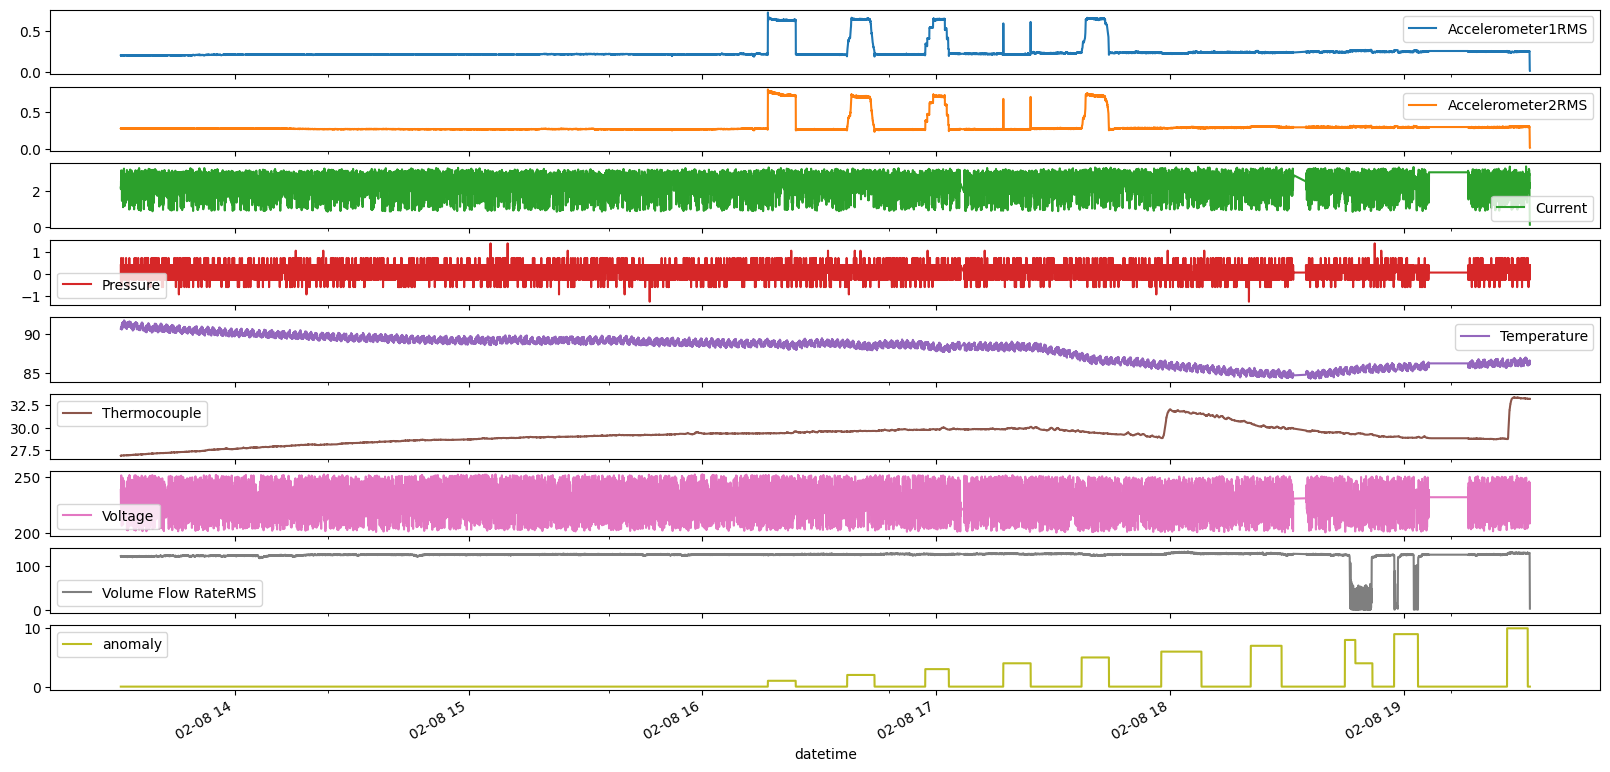

In [7]:
dataframe_20200208.plot(subplots=True, figsize=(20, 10), sharex=True)

In [8]:
dataframe_20200208.anomaly.unique()

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

array([0., 8., 4.])

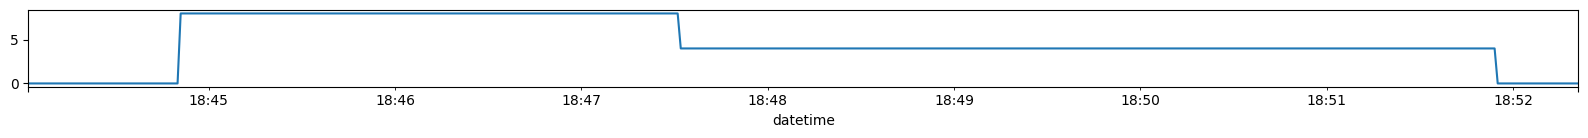

In [9]:
dataframe_20200208[18500:19000].anomaly.plot(subplots=True, figsize=(20, 1))
dataframe_20200208[18500:19000].anomaly.unique()

In [12]:
dataframe_20200208[18500:19000].anomaly.iloc[np.where(dataframe_20200208[18500:19000].anomaly==4.0)[0]] = 8.0
dataframe_20200208[18500:19000].anomaly.unique()

array([0., 8.])

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

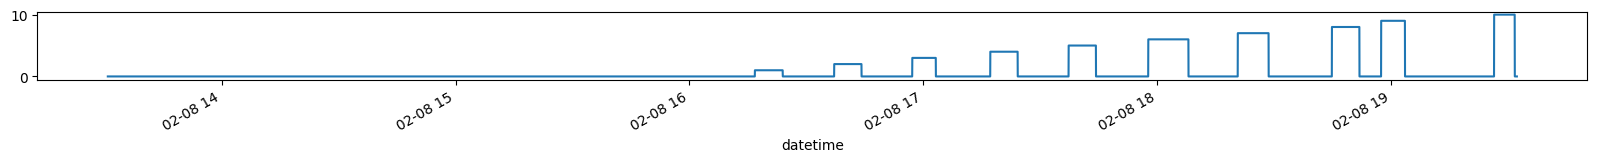

In [13]:
dataframe_20200208.anomaly.plot(subplots=True, figsize=(20, 1))
dataframe_20200208.anomaly.unique()

In [14]:
data = [
    (
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\1.csv", 11, "Fluid Leaks"),
    ),
    (
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\2.csv", 11, "Fluid Leaks"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\3.csv", 11, "Fluid Leaks"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\other\4.csv", 11, "Fluid Leaks"),
    ),
]

dataframe_20200301 = pd.DataFrame()
for group_data in data:
        
    tmp_df = pd.DataFrame()
    for path, anomaly_id, anomaly_desc in group_data:
        
        dataframe = pd.read_csv(path)
        dataframe.anomaly = dataframe.anomaly.mul(anomaly_id)
        tmp_df = pd.concat([tmp_df, dataframe], ignore_index=True)
        # print(path, dataframe_20200301.shape, dataframe.shape, tmp_df.shape)

    tmp_df.set_index(pd.to_datetime(tmp_df.datetime), drop=True, inplace=True)
    tmp_df.drop(columns=["datetime", "changepoint"], inplace=True)
    tmp_df = tmp_df.resample("1s").mean(numeric_only=True)
    tmp_df.ffill(inplace=True)
    
    dataframe_20200301 = pd.concat([dataframe_20200301, tmp_df], ignore_index=False)

dataframe_20200301

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly
datetime,,,,,,,,,
2020-03-01 15:44:06,0.082065,0.133521,1.277940,0.054711,92.2562,22.2577,209.639,76.0197,0.0
2020-03-01 15:44:07,0.082724,0.132378,1.121180,-0.273216,92.0144,22.2577,221.250,76.9806,0.0
2020-03-01 15:44:08,0.081648,0.139038,1.932420,0.054711,92.2413,22.2748,236.615,76.0197,0.0
2020-03-01 15:44:09,0.083335,0.132742,1.259620,-0.273216,92.2438,22.2657,230.375,77.0000,0.0
2020-03-01 15:44:10,0.082272,0.133171,1.597730,0.054711,92.3611,22.2591,249.701,77.0000,0.0
...,...,...,...,...,...,...,...,...,...
2020-03-01 17:20:45,0.081223,0.133877,0.933787,0.054711,87.4189,22.0303,225.264,76.0000,11.0
2020-03-01 17:20:46,0.081839,0.130513,1.961080,0.054711,87.4094,22.0370,216.774,76.0000,11.0
2020-03-01 17:20:47,0.080642,0.135223,1.743560,0.054711,87.5552,22.0357,213.523,76.0000,11.0


array([<Axes: xlabel='datetime'>, <Axes: xlabel='datetime'>,
       <Axes: xlabel='datetime'>, <Axes: xlabel='datetime'>,
       <Axes: xlabel='datetime'>, <Axes: xlabel='datetime'>,
       <Axes: xlabel='datetime'>, <Axes: xlabel='datetime'>,
       <Axes: xlabel='datetime'>], dtype=object)

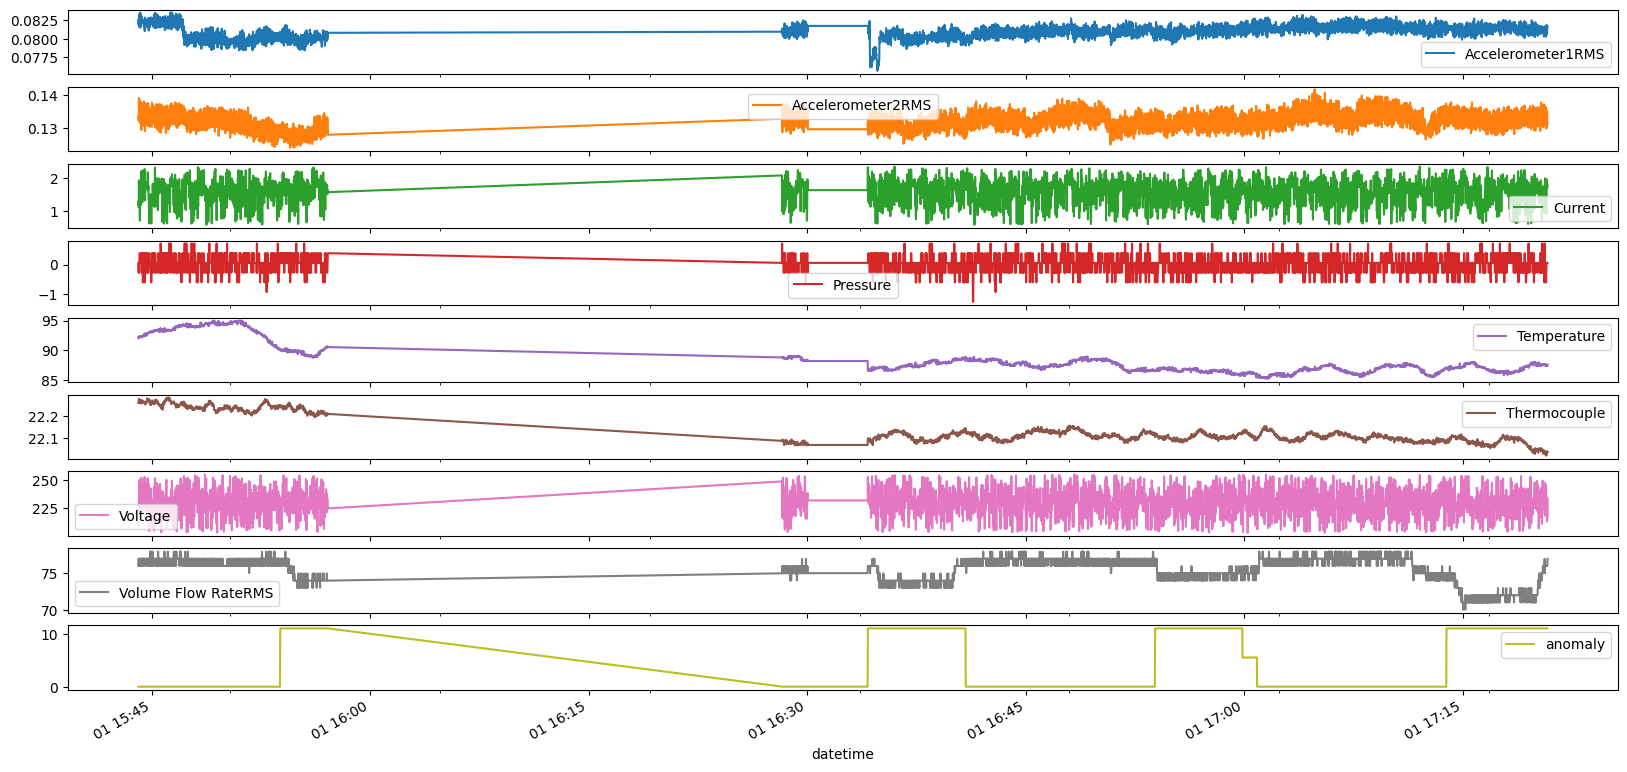

In [19]:
dataframe_20200301.plot(subplots=True, figsize=(20, 10))

In [20]:
dataframe_20200301.anomaly.unique()

array([ 0. , 11. ,  5.5])

array([ 0. , 11. ,  5.5])

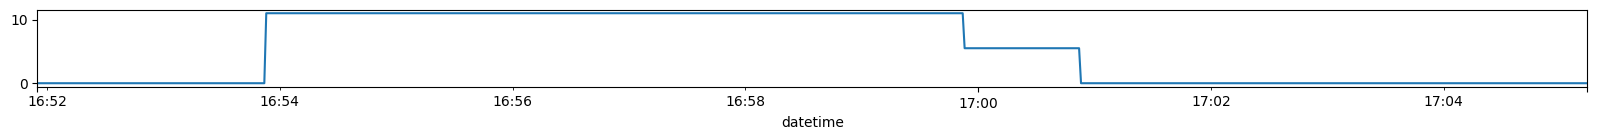

In [21]:
dataframe_20200301[2200:3000].anomaly.plot(subplots=True, figsize=(20, 1))
dataframe_20200301[2200:3000].anomaly.unique()

In [22]:
dataframe_20200301[2200:3000].anomaly.iloc[np.where(dataframe_20200301[2200:3000].anomaly==5.5)[0]] = 11.0
dataframe_20200301[2200:3000].anomaly.unique()

array([ 0., 11.])

array([ 0., 11.])

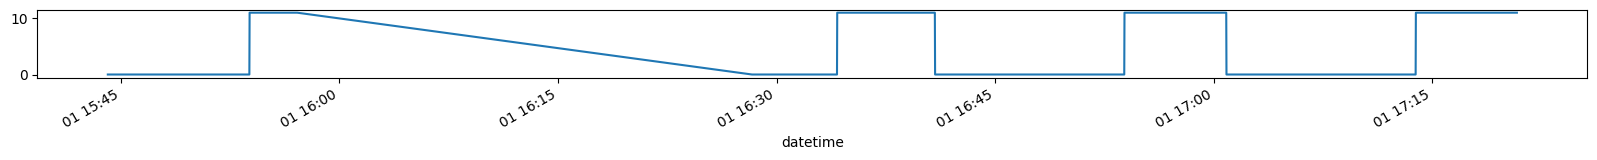

In [23]:
dataframe_20200301.anomaly.plot(subplots=True, figsize=(20, 1))
dataframe_20200301.anomaly.unique()

In [24]:
data = [
    (
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\0.csv", 12, "Inlet Valve Malfunction"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\1.csv", 12, "Inlet Valve Malfunction"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\2.csv", 12, "Inlet Valve Malfunction"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\3.csv", 12, "Inlet Valve Malfunction"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\4.csv", 12, "Inlet Valve Malfunction"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\5.csv", 12, "Inlet Valve Malfunction"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\6.csv", 12, "Inlet Valve Malfunction"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\7.csv", 12, "Inlet Valve Malfunction"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\8.csv", 12, "Inlet Valve Malfunction"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\9.csv", 12, "Inlet Valve Malfunction"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\10.csv", 12, "Inlet Valve Malfunction"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\11.csv", 12, "Inlet Valve Malfunction"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\12.csv", 12, "Inlet Valve Malfunction"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\13.csv", 12, "Inlet Valve Malfunction"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\14.csv", 12, "Inlet Valve Malfunction"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve1\15.csv", 12, "Inlet Valve Malfunction"),

    ),
    (
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve2\0.csv", 13, "Outlet Valve Malfunction"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve2\1.csv", 13, "Outlet Valve Malfunction"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve2\2.csv", 13, "Outlet Valve Malfunction"),
        (r"..\..\datasets\Skoltech_Anomaly_Benchmark\valve2\3.csv", 13, "Outlet Valve Malfunction"),
    ),
]

dataframe_20200309 = pd.DataFrame()
for group_data in data:
        
    tmp_df = pd.DataFrame()
    for path, anomaly_id, anomaly_desc in group_data:
        
        dataframe = pd.read_csv(path)
        dataframe.anomaly = dataframe.anomaly.mul(anomaly_id)
        tmp_df = pd.concat([tmp_df, dataframe], ignore_index=True)
        # print(path, dataframe_20200309.shape, dataframe.shape, tmp_df.shape)

    tmp_df.set_index(pd.to_datetime(tmp_df.datetime), drop=True, inplace=True)
    tmp_df.drop(columns=["datetime", "changepoint"], inplace=True)
    tmp_df = tmp_df.resample("1s").mean(numeric_only=True)
    tmp_df.ffill(inplace=True)
    
    dataframe_20200309 = pd.concat([dataframe_20200309, tmp_df], ignore_index=False)

dataframe_20200309

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly
datetime,,,,,,,,,
2020-03-09 10:14:33,0.026588,0.040111,1.330200,0.054711,79.3366,26.0199,233.062,32.0000,0.0
2020-03-09 10:14:34,0.026170,0.040453,1.353990,0.382638,79.5158,26.0258,236.040,32.0000,0.0
2020-03-09 10:14:35,0.026199,0.039419,1.540060,0.710565,79.3756,26.0265,251.380,32.0000,0.0
2020-03-09 10:14:36,0.026027,0.039641,1.334580,0.382638,79.6097,26.0393,234.392,32.0000,0.0
2020-03-09 10:14:37,0.026290,0.040273,1.078510,-0.273216,79.6109,26.0420,225.342,32.0000,0.0
...,...,...,...,...,...,...,...,...,...
2020-03-09 17:14:05,0.027067,0.038430,0.988875,0.054711,69.6731,24.1046,230.729,32.9562,0.0
2020-03-09 17:14:06,0.027067,0.038430,0.988875,0.054711,69.6731,24.1046,230.729,32.9562,0.0
2020-03-09 17:14:07,0.027582,0.038836,0.588439,0.054711,69.6959,24.1020,233.443,32.0000,0.0


array([<Axes: xlabel='datetime'>, <Axes: xlabel='datetime'>,
       <Axes: xlabel='datetime'>, <Axes: xlabel='datetime'>,
       <Axes: xlabel='datetime'>, <Axes: xlabel='datetime'>,
       <Axes: xlabel='datetime'>, <Axes: xlabel='datetime'>,
       <Axes: xlabel='datetime'>], dtype=object)

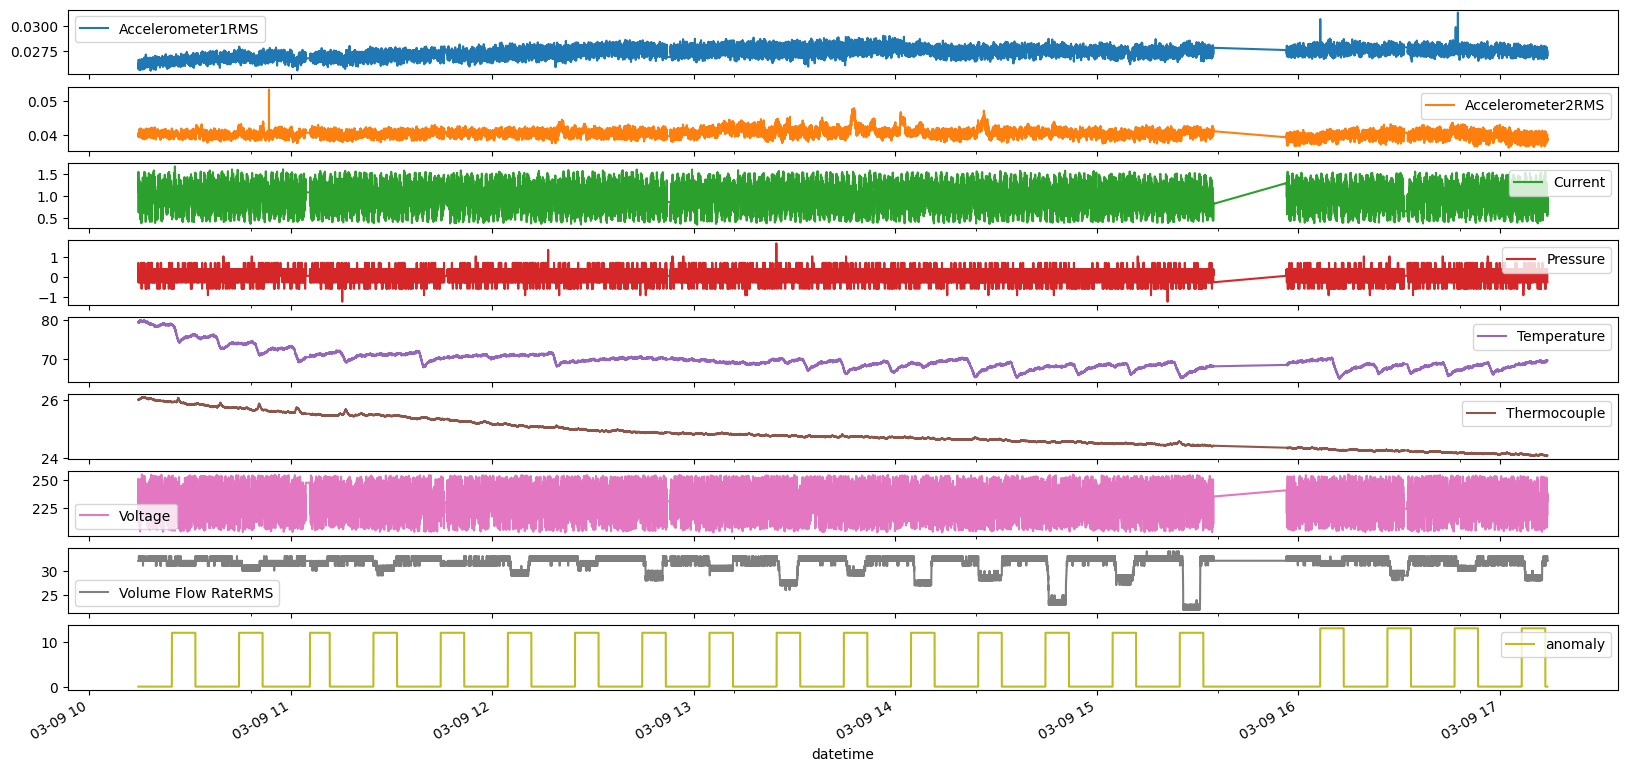

In [25]:
dataframe_20200309.plot(subplots=True, figsize=(20, 10))

In [26]:
dataframe_20200309.anomaly.unique()

array([ 0., 12., 13.])

In [29]:
dataframe_20200208.dfi.export(r"..\..\datasets\Skoltech_Anomaly_Benchmark\plots\dataframe_20200208.png", max_rows=4)
dataframe_20200301.dfi.export(r"..\..\datasets\Skoltech_Anomaly_Benchmark\plots\dataframe_20200301.png", max_rows=4)
dataframe_20200309.dfi.export(r"..\..\datasets\Skoltech_Anomaly_Benchmark\plots\dataframe_20200309.png", max_rows=4)

In [30]:
skab_dataframe = pd.concat([dataframe_20200208, dataframe_20200301, dataframe_20200309])
skab_dataframe

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly
datetime,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.169750,0.382638,90.6454,26.8508,238.852,122.6640,0.0
2020-02-08 13:30:48,0.203153,0.277857,2.079990,-0.273216,90.7978,26.8639,227.943,122.3380,0.0
2020-02-08 13:30:49,0.203153,0.277857,2.079990,-0.273216,90.7978,26.8639,227.943,122.3380,0.0
2020-02-08 13:30:50,0.202054,0.275790,2.525770,0.382638,90.7730,26.8603,223.486,121.3380,0.0
2020-02-08 13:30:51,0.203595,0.278101,2.497420,0.054711,90.8424,26.8616,244.904,121.6640,0.0
...,...,...,...,...,...,...,...,...,...
2020-03-09 17:14:05,0.027067,0.038430,0.988875,0.054711,69.6731,24.1046,230.729,32.9562,0.0
2020-03-09 17:14:06,0.027067,0.038430,0.988875,0.054711,69.6731,24.1046,230.729,32.9562,0.0
2020-03-09 17:14:07,0.027582,0.038836,0.588439,0.054711,69.6959,24.1020,233.443,32.0000,0.0


In [ ]:
skab_dataframe.Pressure.value_counts()

AttributeError: 'Series' object has no attribute 'dfi'

#### Moscos Atmospheric Pressure Datasource
1) https://weatherspark.com/h/d/100524/2020/2/8/Historical-Weather-on-Saturday-February-8-2020-in-Moscow-Russia#Figures-Pressure
2) https://weatherspark.com/h/d/100524/2020/3/1/Historical-Weather-on-Sunday-March-1-2020-in-Moscow-Russia#Figures-Pressure
3) https://weatherspark.com/h/d/100524/2020/3/9/Historical-Weather-on-Monday-March-9-2020-in-Moscow-Russia#Figures-Pressure

In [32]:
atmospheric_pressure_moscow_20200208 = [30.12, 30.09, 30.12, 30.12, 30.12, 30.12, 30.12, 30.12, 30.12, 30.12, 30.15, 30.15, 30.15] # in inches of mercuryv(inHg)
atmospheric_pressure_moscow_20200301 = [29.74, 29.74, 29.74, 29.71, 29.71] # in inches of mercuryv(inHg)
atmospheric_pressure_moscow_20200309 = [30.09, 30.09, 30.09, 30.09, 30.09, 30.09, 30.09, 30.09, 30.09, 30.09, 30.09, 30.06, 30.06, 30.06, 30.06, 30.06] # in inches of mercuryv(inHg)
dataframe_20200208["Pressure"] = dataframe_20200208["Pressure"] + (np.mean(atmospheric_pressure_moscow_20200208)/29.53)
dataframe_20200301["Pressure"] = dataframe_20200301["Pressure"] + (np.mean(atmospheric_pressure_moscow_20200301)/29.53)
dataframe_20200309["Pressure"] = dataframe_20200309["Pressure"] + (np.mean(atmospheric_pressure_moscow_20200309)/29.53)

In [33]:
skab_dataframe = pd.concat([dataframe_20200208, dataframe_20200301, dataframe_20200309])
skab_dataframe

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly
datetime,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.169750,1.402774,90.6454,26.8508,238.852,122.6640,0.0
2020-02-08 13:30:48,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,0.0
2020-02-08 13:30:49,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,0.0
2020-02-08 13:30:50,0.202054,0.275790,2.525770,1.402774,90.7730,26.8603,223.486,121.3380,0.0
2020-02-08 13:30:51,0.203595,0.278101,2.497420,1.074847,90.8424,26.8616,244.904,121.6640,0.0
...,...,...,...,...,...,...,...,...,...
2020-03-09 17:14:05,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,0.0
2020-03-09 17:14:06,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,0.0
2020-03-09 17:14:07,0.027582,0.038836,0.588439,1.073357,69.6959,24.1020,233.443,32.0000,0.0


In [34]:
skab_dataframe.Pressure.value_counts()

Pressure
 1.073357    13315
 1.074847    11978
 1.402774     5435
 1.401284     4957
 0.745430     4258
 0.746920     2790
 1.061416     2278
 1.730701      794
 0.733489      794
 0.417503      694
 1.389343      615
 1.729211      610
 0.418993      373
 0.405562      172
 1.717270       72
 0.089576       18
 2.058626       15
 2.057136       13
 0.091066        6
-0.236864        4
 2.386556        3
-0.250295        2
 0.077635        2
-0.238354        2
 2.385066        1
 2.712996        1
Name: count, dtype: int64

In [35]:
skab_dataframe["Pressure"] = skab_dataframe["Pressure"].apply(lambda x: x if x >= 0 else 0)
skab_dataframe.Pressure.value_counts()

Pressure
1.073357    13315
1.074847    11978
1.402774     5435
1.401284     4957
0.745430     4258
0.746920     2790
1.061416     2278
1.730701      794
0.733489      794
0.417503      694
1.389343      615
1.729211      610
0.418993      373
0.405562      172
1.717270       72
0.089576       18
2.058626       15
2.057136       13
0.000000        8
0.091066        6
2.386556        3
0.077635        2
2.385066        1
2.712996        1
Name: count, dtype: int64

In [36]:
anomalies = {
                0: "No Anomaly",

                1: "Sharp - Rotor Imbalance",
                2: "Linear - Rotor Imbalance",
                3: "Step - Rotor Imbalance",
                4: "Dirac - Rotor Imbalance",
                5: "Exponential - Rotor Imbalance",
                
                6: "Slow Water Increase (Circuit)",
                7: "Sharp Water Increase (Circuit)",
                
                8: "Water Drainage (Cavitation)",
                9: "Two-phase Supply (Cavitation)",
                10: "Water Temperature Increase",
                
                11: "Fluid Leaks",
                12: "Inlet Valve Malfunction",
                13: "Outlet Valve Malfunction",
}

anomaly_desc = [anomalies[id] for id in skab_dataframe.anomaly]
skab_dataframe = skab_dataframe.assign(description=anomaly_desc)
skab_dataframe

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,description
datetime,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.169750,1.402774,90.6454,26.8508,238.852,122.6640,0.0,No Anomaly
2020-02-08 13:30:48,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,0.0,No Anomaly
2020-02-08 13:30:49,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,0.0,No Anomaly
2020-02-08 13:30:50,0.202054,0.275790,2.525770,1.402774,90.7730,26.8603,223.486,121.3380,0.0,No Anomaly
2020-02-08 13:30:51,0.203595,0.278101,2.497420,1.074847,90.8424,26.8616,244.904,121.6640,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...
2020-03-09 17:14:05,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,0.0,No Anomaly
2020-03-09 17:14:06,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,0.0,No Anomaly
2020-03-09 17:14:07,0.027582,0.038836,0.588439,1.073357,69.6959,24.1020,233.443,32.0000,0.0,No Anomaly


In [37]:
skab_dataframe.description.unique()

array(['No Anomaly', 'Sharp - Rotor Imbalance',
       'Linear - Rotor Imbalance', 'Step - Rotor Imbalance',
       'Dirac - Rotor Imbalance', 'Exponential - Rotor Imbalance',
       'Slow Water Increase (Circuit)', 'Sharp Water Increase (Circuit)',
       'Water Drainage (Cavitation)', 'Two-phase Supply (Cavitation)',
       'Water Temperature Increase', 'Fluid Leaks',
       'Inlet Valve Malfunction', 'Outlet Valve Malfunction'],
      dtype=object)

In [38]:
path = r"..\..\datasets\Skoltech_Anomaly_Benchmark\preprocessed_skab_dataset.csv"
skab_dataframe.to_csv(path, index=True)